# Flight Delay Prediction — Data Cleaning
**Author:** Justin Engwall  
**Date:** June 2026  
**Course:** DATASCI 207  

## Overview
This notebook handles initial data cleaning for the BTS Airline On-Time Statistics dataset.
Tasks include:
- Loading raw data from the TranStats database
- Inspecting shape, dtypes, and missing values
- Dropping or imputing missing entries
- Standardizing column names
- Exporting a cleaned dataset for EDA and modeling



## Import libraries

In [1]:
import numpy as np
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

/Users/justin/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/justin/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## Data ingestion
### Data Sources
Flight data is from Jan 1, 2022 to Jan 1, 2026.     
Departure and Arrival Aiport: Atlanta, GA: Hartsfield-Jackson Atlanta International (ATL).   
Airlines: Delta (DL), American (AA), Southwest (WN), United (UA)  

U.S. Department of Transportation — Bureau of Transportation Statistics (BTS)  
https://www.transtats.bts.gov/ontime

Hourly weather observations - NOAA Global Historical Climatology Network  
https://www.ncei.noaa.gov/access/search/data-search/global-historical-climatology-network-hourly

FAA Aircraft Registry - all registered US aircraft (type, manufacturer, year, engine type, # of seats)  
https://registry.faa.gov/aircraftinquiry/Search/NNumberInquiry

FAA N-Number - lookup for individual aircraft  
https://www.faa.gov/licenses_certificates/aircraft_certification/aircraft_registry/releasable_aircraft_download?utm_source=chatgpt.com

## Transtats Flight Data - Atlanta (Departures & Arrivals)

In [2]:
# set location for directory
os.chdir('/Users/justin/DATASCI207/207-Summer26-FinalProject-MLModel/datasets')

# airlines in dataset
airlines = ['AA', 'DL', 'WN', 'UA']

# load ATL arrival data
arrivals_df = []
# read each .csv arrival for each airline
for airline in airlines:
    df = pd.read_csv(f"ATL_{airline}_Arrivals.csv", skiprows=7)
    arrivals_df.append(df)

atl_arrivals = pd.concat(arrivals_df, ignore_index=True)

# load ATL departure data
departures_df = []
# read each .csv arrival for each airline
for airline in airlines:
    df = pd.read_csv(f"ATL_{airline}_Departures.csv", skiprows=7)
    departures_df.append(df)

atl_departures = pd.concat(departures_df, ignore_index=True)

In [3]:
# take a peak at the arrival data
# atl_arrivals.head
print("ATL arrivals shape:", atl_arrivals.shape)
print("ATL departures shape:", atl_departures.shape)
print("The data type of arrivals:", atl_arrivals.dtypes)

ATL arrivals shape: (1161149, 17)
ATL departures shape: (1161257, 17)
The data type of arrivals: Carrier Code                                    str
Date (MM/DD/YYYY)                               str
Flight Number                               float64
Tail Number                                     str
Origin Airport                                  str
Scheduled Arrival Time                          str
Actual Arrival Time                             str
Scheduled Elapsed Time (Minutes)            float64
Actual Elapsed Time (Minutes)               float64
Arrival Delay (Minutes)                     float64
Wheels-on Time                                  str
Taxi-In time (Minutes)                      float64
Delay Carrier (Minutes)                     float64
Delay Weather (Minutes)                     float64
Delay National Aviation System (Minutes)    float64
Delay Security (Minutes)                    float64
Delay Late Aircraft Arrival (Minutes)       float64
dtype: object


In [4]:
## arrival conversion
# replace hour 24:00 with 00:00 before converting to datetime
atl_arrivals['Actual Arrival Time'] = atl_arrivals['Actual Arrival Time'].str.replace('24:00', '00:00')
atl_arrivals['Wheels-on Time'] = atl_arrivals['Wheels-on Time'].str.replace('24:00', '00:00')
atl_arrivals['Scheduled Arrival Time'] = atl_arrivals['Scheduled Arrival Time'].str.replace('24:00', '00:00')

# convert arrival time string to datetime
atl_arrivals['Date (MM/DD/YYYY)'] = pd.to_datetime(atl_arrivals['Date (MM/DD/YYYY)'])
atl_arrivals['Actual Arrival Time'] = pd.to_datetime(atl_arrivals['Actual Arrival Time'], format='%H:%M').dt.time
atl_arrivals['Wheels-on Time'] = pd.to_datetime(atl_arrivals['Wheels-on Time'], format='%H:%M').dt.time
atl_arrivals['Scheduled Arrival Time'] = pd.to_datetime(atl_arrivals['Scheduled Arrival Time'], format='%H:%M').dt.time

## departure conversion
atl_departures['Date (MM/DD/YYYY)'] = pd.to_datetime(atl_departures['Date (MM/DD/YYYY)'])
atl_departures['Scheduled departure time'] = atl_departures['Scheduled departure time'].str.replace('24:00', '00:00')
atl_departures['Actual departure time'] = atl_departures['Actual departure time'].str.replace('24:00', '00:00')
atl_departures['Wheels-off time'] = atl_departures['Wheels-off time'].str.replace('24:00', '00:00')

# covert departure time string to datetime
atl_departures['Scheduled departure time'] = pd.to_datetime(atl_departures['Scheduled departure time'], format='%H:%M').dt.time
atl_departures['Actual departure time'] = pd.to_datetime(atl_departures['Actual departure time'], format='%H:%M').dt.time
atl_departures['Wheels-off time'] = pd.to_datetime(atl_departures['Wheels-off time'], format='%H:%M').dt.time

## verify the conversion
print(atl_arrivals[['Date (MM/DD/YYYY)', 'Scheduled Arrival Time', 'Actual Arrival Time']].dtypes)
print(atl_arrivals[['Date (MM/DD/YYYY)', 'Scheduled Arrival Time', 'Actual Arrival Time']].head())
print(atl_departures[['Date (MM/DD/YYYY)', 'Scheduled departure time', 'Actual departure time']].dtypes)
print(atl_departures[['Date (MM/DD/YYYY)', 'Scheduled departure time', 'Actual departure time']].head())
print(atl_arrivals['Date (MM/DD/YYYY)'].dtype)
print(atl_departures['Date (MM/DD/YYYY)'].dtype)

Date (MM/DD/YYYY)         datetime64[us]
Scheduled Arrival Time            object
Actual Arrival Time               object
dtype: object
  Date (MM/DD/YYYY) Scheduled Arrival Time Actual Arrival Time
0        2022-01-01               23:29:00            23:19:00
1        2022-01-01               23:40:00            23:31:00
2        2022-01-01               21:53:00            21:42:00
3        2022-01-01               15:52:00            16:57:00
4        2022-01-01               13:25:00            13:43:00
Date (MM/DD/YYYY)           datetime64[us]
Scheduled departure time            object
Actual departure time               object
dtype: object
  Date (MM/DD/YYYY) Scheduled departure time Actual departure time
0        2022-01-01                 08:36:00              08:32:00
1        2022-01-01                 14:05:00              14:24:00
2        2022-01-01                 17:00:00              17:51:00
3        2022-01-01                 16:29:00              16:24:00
4      

In [5]:
print(atl_departures.columns.tolist())

['Carrier Code', 'Date (MM/DD/YYYY)', 'Flight Number', 'Tail Number', 'Destination Airport', 'Scheduled departure time', 'Actual departure time', 'Scheduled elapsed time (Minutes)', 'Actual elapsed time (Minutes)', 'Departure delay (Minutes)', 'Wheels-off time', 'Taxi-Out time (Minutes)', 'Delay Carrier (Minutes)', 'Delay Weather (Minutes)', 'Delay National Aviation System (Minutes)', 'Delay Security (Minutes)', 'Delay Late Aircraft Arrival (Minutes)']


## NOAA Weather Data - Atlanta (2022-2026)

In [6]:
# load all weather files from directory
weather_files = glob.glob('ATL_NOAA_*.psv')
weather = pd.concat((pd.read_csv(f, sep='|') for f in weather_files), ignore_index=True)

# verify weather data
print("Weather shape:", weather.shape)
print("\nWeather columns:", weather.columns.tolist())
print("\nWeather dtypes:\n", weather.dtypes)
weather.shape
# 88285 rows and 329 columns <- that is a lot

/var/folders/k_/kqcbxzrj2694b_fn8zcvy9tr0000gn/T/ipykernel_10411/2308022532.py:3: DtypeWarning: Columns (0: temperature_Quality_Code, 1: dew_point_temperature_Quality_Code, 2: wind_direction_Quality_Code, 3: wind_speed_Quality_Code, 4: precipitation_Quality_Code, 5: pres_wx_MW2, 6: pres_wx_MW2_Report_Type, 7: pres_wx_MW2_Source_Station_ID, 8: visibility_Quality_Code, 9: sky_cover_summation_1_Quality_Code, 10: sky_cover_summation_2_Quality_Code, 11: sky_cover_summation_3_Quality_Code, 12: sky_cover_summation_4_Quality_Code, 13: sky_cover_summation_baseht_1_Quality_Code, 14: sky_cover_summation_baseht_2_Quality_Code, 15: sky_cover_summation_baseht_3_Quality_Code, 16: sky_cover_summation_baseht_4_Measurement_Code, 17: sky_cover_summation_baseht_4_Quality_Code) have mixed types. Specify dtype option on import or set low_memory=False.
  weather = pd.concat((pd.read_csv(f, sep='|') for f in weather_files), ignore_index=True)
/var/folders/k_/kqcbxzrj2694b_fn8zcvy9tr0000gn/T/ipykernel_10411/23

Weather shape: (88285, 329)

Weather columns: ['STATION', 'Station_name', 'DATE', 'Year', 'Month', 'Day', 'Hour', 'Minute', 'LATITUDE', 'LONGITUDE', 'ELEVATION', 'temperature', 'temperature_Measurement_Code', 'temperature_Quality_Code', 'temperature_Report_Type', 'temperature_Source_Code', 'temperature_Source_Station_ID', 'dew_point_temperature', 'dew_point_temperature_Measurement_Code', 'dew_point_temperature_Quality_Code', 'dew_point_temperature_Report_Type', 'dew_point_temperature_Source_Code', 'dew_point_temperature_Source_Station_ID', 'station_level_pressure', 'station_level_pressure_Measurement_Code', 'station_level_pressure_Quality_Code', 'station_level_pressure_Report_Type', 'station_level_pressure_Source_Code', 'station_level_pressure_Source_Station_ID', 'sea_level_pressure', 'sea_level_pressure_Measurement_Code', 'sea_level_pressure_Quality_Code', 'sea_level_pressure_Report_Type', 'sea_level_pressure_Source_Code', 'sea_level_pressure_Source_Station_ID', 'wind_direction', 'win

(88285, 329)

In [7]:
print("Null values in weather data:")
print(weather.isnull().sum())

Null values in weather data:
STATION                      0
Station_name                 0
DATE                         0
Year                         0
Month                        0
                         ...  
REM_Measurement_Code     88285
REM_Quality_Code         88285
REM_Report_Type          32844
REM_Source_Code          32844
REM_Source_Station_ID    32844
Length: 329, dtype: int64


In [8]:
# Null percentage per column
null_pct = (weather.isnull().sum() / len(weather) * 100).round(2)
print("Null percentage per column:")
print(null_pct)

Null percentage per column:
STATION                    0.0
Station_name               0.0
DATE                       0.0
Year                       0.0
Month                      0.0
                         ...  
REM_Measurement_Code     100.0
REM_Quality_Code         100.0
REM_Report_Type           37.2
REM_Source_Code           37.2
REM_Source_Station_ID     37.2
Length: 329, dtype: float64


In [9]:
weather.head()
print(weather.columns.tolist())

['STATION', 'Station_name', 'DATE', 'Year', 'Month', 'Day', 'Hour', 'Minute', 'LATITUDE', 'LONGITUDE', 'ELEVATION', 'temperature', 'temperature_Measurement_Code', 'temperature_Quality_Code', 'temperature_Report_Type', 'temperature_Source_Code', 'temperature_Source_Station_ID', 'dew_point_temperature', 'dew_point_temperature_Measurement_Code', 'dew_point_temperature_Quality_Code', 'dew_point_temperature_Report_Type', 'dew_point_temperature_Source_Code', 'dew_point_temperature_Source_Station_ID', 'station_level_pressure', 'station_level_pressure_Measurement_Code', 'station_level_pressure_Quality_Code', 'station_level_pressure_Report_Type', 'station_level_pressure_Source_Code', 'station_level_pressure_Source_Station_ID', 'sea_level_pressure', 'sea_level_pressure_Measurement_Code', 'sea_level_pressure_Quality_Code', 'sea_level_pressure_Report_Type', 'sea_level_pressure_Source_Code', 'sea_level_pressure_Source_Station_ID', 'wind_direction', 'wind_direction_Measurement_Code', 'wind_direction

## FAA Aircraft Registry

In [10]:
# path to FAA master data file
aircraft = pd.read_csv('FAA/MASTER.txt', sep=',')

# see the details of dataset
print("Aircraft shape:", aircraft.shape)
print("\nAircraft columns:", aircraft.columns.tolist())
aircraft.head()

Aircraft shape: (313930, 35)

Aircraft columns: ['N-NUMBER', 'SERIAL NUMBER', 'MFR MDL CODE', 'ENG MFR MDL', 'YEAR MFR', 'TYPE REGISTRANT', 'NAME', 'STREET', 'STREET2', 'CITY', 'STATE', 'ZIP CODE', 'REGION', 'COUNTY', 'COUNTRY', 'LAST ACTION DATE', 'CERT ISSUE DATE', 'CERTIFICATION', 'TYPE AIRCRAFT', 'TYPE ENGINE', 'STATUS CODE', 'MODE S CODE', 'FRACT OWNER', 'AIR WORTH DATE', 'OTHER NAMES(1)', 'OTHER NAMES(2)', 'OTHER NAMES(3)', 'OTHER NAMES(4)', 'OTHER NAMES(5)', 'EXPIRATION DATE', 'UNIQUE ID', 'KIT MFR', ' KIT MODEL', 'MODE S CODE HEX', 'Unnamed: 34']


,N-NUMBER,SERIAL NUMBER,MFR MDL CODE,ENG MFR MDL,YEAR MFR,TYPE REGISTRANT,NAME,STREET,STREET2,CITY,...,OTHER NAMES(2),OTHER NAMES(3),OTHER NAMES(4),OTHER NAMES(5),EXPIRATION DATE,UNIQUE ID,KIT MFR,KIT MODEL,MODE S CODE HEX,Unnamed: 34
0,100,5334,7100510,17003,1940,1,BENE MARY D ...,PO BOX 329,,KETCHUM,...,...,...,...,...,20270430,600060,,,A004B3,NaN
1,10000,10000,2130004,,,7,9AT LLC ...,511 WEDGEWOOD AVE,,NASHVILLE,...,...,...,...,...,20310831,1443200,,,A00725,NaN
2,10001,A28,9601202,67007,1928,1,STOOS ROBERT A ...,PO BOX 1056,,LAKELAND,...,...,...,...,...,20290228,432072,,,A00726,NaN
3,10004,T18208245,2072738,,,7,ETOS AIR LLC ...,PO BOX 288,,NEW LONDON,...,...,...,...,...,20290331,102879,,,A00729,NaN
4,10006,BG-72,1152020,17026,1955,1,COUTCHES ROBERT HERCULES DBA ...,550 AIRWAY BLVD,,LIVERMORE,...,...,...,...,...,20280229,480110,,,A0072B,NaN


In [11]:
# let's reduce the number of columns in the MASTER.txt data
aircraft_cols = ['N-NUMBER', 'YEAR MFR' , 'TYPE AIRCRAFT', 'TYPE ENGINE', 'MFR MDL CODE', 'ENG MFR MDL']
aircraft = aircraft[aircraft_cols].copy()

# standardize column names and remove invisible chars
aircraft.columns = aircraft.columns.str.strip() # strip space from columns
aircraft['N-NUMBER'] = aircraft['N-NUMBER'].str.strip() # strip space from N-number entries
aircraft['MFR MDL CODE'] = aircraft['MFR MDL CODE'].str.strip()
aircraft['ENG MFR MDL'] = aircraft['ENG MFR MDL'].str.strip()

# Move aircraft_ref and engine_ref here

In [12]:
# let's load the aircraft manufacturer data
aircraft_ref = pd.read_csv('/Users/justin/DATASCI207/207-Summer26-FinalProject-MLModel/datasets/FAA/ACFTREF.txt')
print("Aircraft reference shape:", aircraft_ref.shape)
print("Aircraft reference headings:", aircraft_ref.columns.tolist())

Aircraft reference shape: (93817, 14)
Aircraft reference headings: ['CODE', 'MFR', 'MODEL', 'TYPE-ACFT', 'TYPE-ENG', 'AC-CAT', 'BUILD-CERT-IND', 'NO-ENG', 'NO-SEATS', 'AC-WEIGHT', 'SPEED', 'TC-DATA-SHEET', 'TC-DATA-HOLDER', 'Unnamed: 13']


In [13]:
aircraft_ref.head()

,CODE,MFR,MODEL,TYPE-ACFT,TYPE-ENG,AC-CAT,BUILD-CERT-IND,NO-ENG,NO-SEATS,AC-WEIGHT,SPEED,TC-DATA-SHEET,TC-DATA-HOLDER,Unnamed: 13
0,0020901,AAR AIRLIFT GROUP INC,UH-60A,6,3,1,0,2,15,CLASS 3,0,,...,NaN
1,0030109,EXLINE ACE-C,ACE-C,4,1,1,1,1,1,CLASS 1,82,,...,NaN
2,003010D,DELEBAUGH,P,4,1,1,1,1,1,CLASS 1,82,,...,NaN
3,003010H,DAL PORTO,BABY ACE D,4,1,1,1,1,1,CLASS 1,82,,...,NaN
4,003010P,DUNN,BABY ACE,4,1,1,1,1,1,CLASS 1,82,,...,NaN


In [14]:
# let's do the same thing for engine reference 
engine_ref = pd.read_csv('/Users/justin/DATASCI207/207-Summer26-FinalProject-MLModel/datasets/FAA/ENGINE.txt')
print("Engine reference shape:", engine_ref.shape)
print("Engine reference headings:", engine_ref.columns.tolist())

Engine reference shape: (4745, 7)
Engine reference headings: ['CODE', 'MFR', 'MODEL', 'TYPE', 'HORSEPOWER', 'THRUST', 'Unnamed: 6']


In [15]:
engine_ref.head()

,CODE,MFR,MODEL,TYPE,HORSEPOWER,THRUST,Unnamed: 6
0,0,NONE,NONE,0,0,0,NaN
1,401,A.C.E.,HIDR MARK III,1,95,0,NaN
2,402,A.C.E.,UPRI MARK III,1,100,0,NaN
3,450,AEROMOMENT,AM13 SERIES,8,100,0,NaN
4,452,AEROMOMENT,AM15 SERIES,8,117,0,NaN


# Let's merge the datasets at the beginning

In [16]:
# add in the aircraft reference information like MFR, MODEL, etc.
aircraft = pd.merge(
    aircraft, # use all columns from aircraft
    aircraft_ref[['CODE', 'MFR', 'MODEL', 'NO-ENG', 'NO-SEATS', 'AC-WEIGHT', 'SPEED']], # columns to keep from aircraft_ref
    left_on='MFR MDL CODE', # use MFR MDL CODE from aicraft for key
    right_on='CODE', # use CODE from aircraft_ref for pairing
    how='left' # merge on the left MASTER.txt data
)

In [17]:
# check datatype of CODE for each dataset
print("Engine ref:\n", engine_ref[['CODE']].dtypes)
print("Aircraft ref:\n", aircraft_ref[['CODE']].dtypes)

# check aircraft df
print("Aircraft master:\n", aircraft[['MFR MDL CODE', 'ENG MFR MDL']].dtypes)

# convert aircraft master 'ENG MFR MDL' to numeric to merge with engine data CODE int65
aircraft['ENG MFR MDL'] = pd.to_numeric(aircraft['ENG MFR MDL'], errors='coerce')

Engine ref:
 CODE    int64
dtype: object
Aircraft ref:
 CODE    str
dtype: object
Aircraft master:
 MFR MDL CODE    str
ENG MFR MDL     str
dtype: object


In [18]:
# verify new data type of aircraft engines
print(aircraft[['MFR MDL CODE', 'ENG MFR MDL']].dtypes)

MFR MDL CODE        str
ENG MFR MDL     float64
dtype: object


In [19]:
# let's add the engine information as well

# we need to convert the datatype for merege to be successful
aircraft = pd.merge(
    aircraft, # use the aircraft as master again
    engine_ref[['CODE', 'MFR', 'MODEL', 'THRUST']], # specific engine information
    left_on='ENG MFR MDL', # match the ENG MFR MDL in MASTER to the specific engine info
    right_on='CODE', # match to the code information in engine_ref
    how='left', # merge to keep all left data
    suffixes=("", '_ENG') # relabel column headers that have same name
)

## FAA EDA

In [20]:
# first pass look at MASTER.txt
print("Aircraft shape after strip:", aircraft.shape)

Aircraft shape after strip: (313930, 17)


In [21]:
# data type of variables
aircraft.dtypes

N-NUMBER             str
YEAR MFR             str
TYPE AIRCRAFT        str
TYPE ENGINE        int64
MFR MDL CODE         str
ENG MFR MDL      float64
CODE                 str
MFR                  str
MODEL                str
NO-ENG             int64
NO-SEATS           int64
AC-WEIGHT            str
SPEED              int64
CODE_ENG         float64
MFR_ENG              str
MODEL_ENG            str
THRUST           float64
dtype: object

In [22]:
# sneak peak
print(aircraft.head())
print(aircraft.describe())

  N-NUMBER YEAR MFR TYPE AIRCRAFT  TYPE ENGINE MFR MDL CODE  ENG MFR MDL  \
0      100     1940             4            1      7100510      17003.0   
1    10000                      4            1      2130004          NaN   
2    10001     1928             4            1      9601202      67007.0   
3    10004                      4            2      2072738          NaN   
4    10006     1955             4            1      1152020      17026.0   

      CODE                             MFR                 MODEL  NO-ENG  \
0  7100510  PIPER                           J3C-65                     1   
1  2130004  CIRRUS DESIGN CORP              SR22T                      1   
2  9601202  WACO                            ASO                        1   
3  2072738  CESSNA                          T182T                      1   
4  1152020  BEECH                           D-45 (T-34B)               1   

   NO-SEATS AC-WEIGHT  SPEED  CODE_ENG     MFR_ENG      MODEL_ENG  THRUST  
0         

### We can use 'MFR MDL CODE' here as the key between MASTER.txt and other supporting files

In [23]:
# missing values
print("Missing value count from data:", aircraft.isnull().sum())

Missing value count from data: N-NUMBER             0
YEAR MFR             0
TYPE AIRCRAFT        0
TYPE ENGINE          0
MFR MDL CODE         0
ENG MFR MDL      37138
CODE                 0
MFR                  0
MODEL                0
NO-ENG               0
NO-SEATS             0
AC-WEIGHT            0
SPEED                0
CODE_ENG         37138
MFR_ENG          37138
MODEL_ENG        37138
THRUST           37138
dtype: int64


In [24]:
# what is the age of our planes?
print(aircraft['YEAR MFR'].describe())

count     313930
unique       117
top             
freq       67786
Name: YEAR MFR, dtype: object


In [25]:
print(aircraft['YEAR MFR'].unique()[:20])

<ArrowStringArray>
['1940', '    ', '1928', '1955', '1966', '1979', '1978', '2002', '2025',
 '1948', '1963', '1972', '1957', '2023', '1954', '1960', '1947', '1973',
 '1951', '1950']
Length: 20, dtype: str


In [26]:
# let's convert the year of aircarft to numberic
aircraft['YEAR MFR'] = pd.to_numeric(aircraft['YEAR MFR'], errors='coerce')

In [27]:
print(aircraft['YEAR MFR'].describe())

count    246144.000000
mean       1983.240810
std          54.598622
min           0.000000
25%        1966.000000
50%        1979.000000
75%        2006.000000
max        2026.000000
Name: YEAR MFR, dtype: float64


In [61]:
# we have a minimum year of 0, which is probably just empty info
print((aircraft['YEAR MFR'] == 0).sum())

# how many aircrafts are manufactured before planes actually existed?
print(aircraft[aircraft['YEAR MFR'] < 1950]['YEAR MFR'].value_counts())

0
Series([], Name: count, dtype: int64)


In [29]:
# let's replace the aircraft years before 1950 with NaN values
aircraft.loc[aircraft['YEAR MFR'] < 1950, 'YEAR MFR'] = np.nan # locate rows with years < 1950, select only YEAR MFR, assign NaN

print("Count of YEAR MFR == 0:", (aircraft['YEAR MFR'] == 0).sum())

Count of YEAR MFR == 0: 0


In [30]:
print(aircraft['YEAR MFR'].describe())
print("\nCount of missing YEAR MFR:", aircraft['YEAR MFR'].isnull().sum())

count    223112.000000
mean       1988.561534
std          21.430410
min        1950.000000
25%        1971.000000
50%        1982.000000
75%        2007.000000
max        2026.000000
Name: YEAR MFR, dtype: float64

Count of missing YEAR MFR: 90818


### We are missing 90,818 aircraft without years. 
### 90818 / 313930 is approx 29% of our FAA entries

### What type of aircraft are there?

1 - Glider
2 - Balloon
3 - Blimp/Dirigible
4 - Fixed wing single engine
5 - Fixed wing multi engine
6 - Rotorcraft
7 - Weight-shift-control
8 - Powered Parachute
9 - Gyroplane
H - Hybrid Lift
O - Other

In [31]:
print(aircraft['TYPE AIRCRAFT'].value_counts())

TYPE AIRCRAFT
4    220868
5     49331
6     27399
2      5249
1      4870
H      2773
8      1910
7      1058
9       404
3        49
O        19
Name: count, dtype: int64


We can see most of our aircraft are:
- #4, which is Fixed wing single engine
- followed by #5, fixed wing multi engine

In [32]:
# let's create a map to assign the aircraft number to a label
aircraft_type_map = {
    '1': 'Glider',
    '2': 'Balloon', # pretty cool but not related for this project
    '3': 'Blimp',
    '4': 'Fixed wing single engine',
    '5': 'Fixed wing multi engine', # the aircraft we would likely be interested in
    '6': 'Rotorcraft',
    '7': 'Weight-shift-control',
    '8': 'Powered Parachute', # interesting
    '9': 'Gyroplane',
    'H': 'Hybrid Lift',
    'O': 'Other'
}

# assign map to TYPE AIRCRAFT
aircraft['TYPE AIRCRAFT LABEL'] = aircraft['TYPE AIRCRAFT'].map(aircraft_type_map)
print(aircraft['TYPE AIRCRAFT LABEL'].value_counts())

TYPE AIRCRAFT LABEL
Fixed wing single engine    220868
Fixed wing multi engine      49331
Rotorcraft                   27399
Balloon                       5249
Glider                        4870
Hybrid Lift                   2773
Powered Parachute             1910
Weight-shift-control          1058
Gyroplane                      404
Blimp                           49
Other                           19
Name: count, dtype: int64


### Most of the aircraft we are concerned with are #5 Fixed wing multi engine.
What are the engine types of the planes in our dataset?

In [33]:
# check engine types
print(aircraft['TYPE ENGINE'].value_counts())

TYPE ENGINE
1     210173
5      27124
8      21275
10     15460
2      14033
3       9723
0       9123
7       5139
4       1797
11        75
9          5
6          3
Name: count, dtype: int64


Type of Engines
0 - None
1 - Reciprocating
2 - Turbo-prop
3 - Turbo-shaft
4 - Turbo-jet
5 - Turbo-fan
6 - Ramjet
7 - 2 Cycle
8 - 4 Cycle
9 – Unknown
10 – Electric
11 - Rotary

In [34]:
# engines also have numeric codes we should map
engine_type_map = {
    0: 'None',
    1: 'Reciprocating',
    2: 'Turbo-prop',
    3: 'Turbo-shaft',
    4: 'Turbo-jet',
    5: 'Turbo-fan',
    6: 'Ramjet',
    7: '2 Cycle',
    8: '4 Cycle',
    9: 'Unknown',
    10: 'Electric',
    11: 'Rotary'
}

# assign the engine type map to the TYPE ENGINE
aircraft['TYPE ENGINE LABEL'] = aircraft['TYPE ENGINE'].map(engine_type_map)
print(aircraft['TYPE ENGINE LABEL'].value_counts())

TYPE ENGINE LABEL
Reciprocating    210173
Turbo-fan         27124
4 Cycle           21275
Electric          15460
Turbo-prop        14033
Turbo-shaft        9723
None               9123
2 Cycle            5139
Turbo-jet          1797
Rotary               75
Unknown               5
Ramjet                3
Name: count, dtype: int64


### #5 Turbo-fan engines are the most common engine used in commercial aircraft (fixed wing multi-engine)

## Let's graph the preliminary analysis

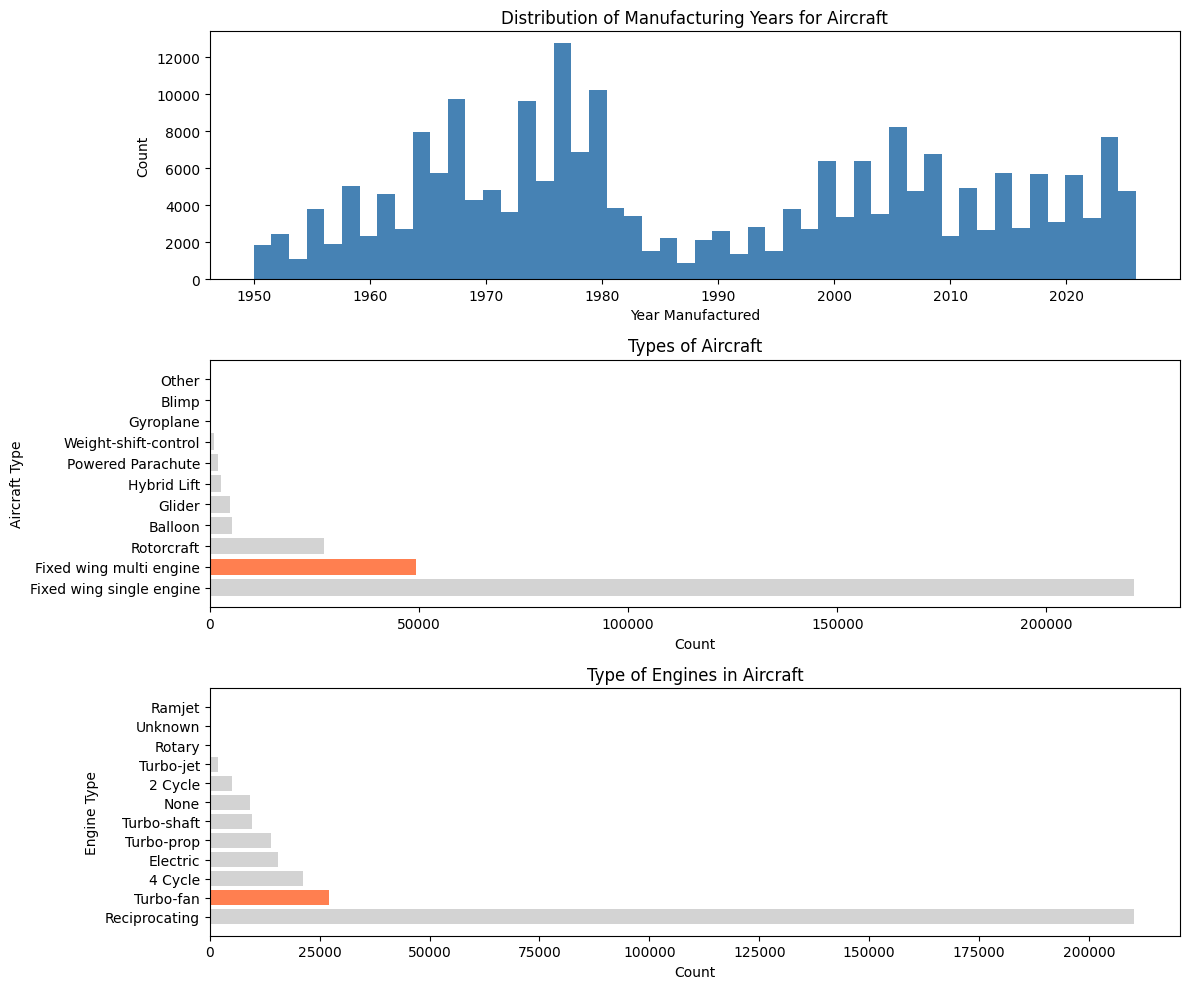

In [35]:
fig, ax = plt.subplots(3, 1, figsize=(12,10))

# graph of the manufacturing years of aircraft in FAA Master.txt
ax[0].hist(aircraft['YEAR MFR'].dropna(), bins=50, color='steelblue')
ax[0].set_title('Distribution of Manufacturing Years for Aircraft')
ax[0].set_xlabel('Year Manufactured')
ax[0].set_ylabel('Count')

# graph showing which types of aircraft are in the dataset
# highlight the aircraft type of interest
type_counts = aircraft['TYPE AIRCRAFT LABEL'].value_counts() # get the count of each aircraft label type
a_colors = ['coral' if label == 'Fixed wing multi engine' else 'lightgrey' for label in type_counts.index]
ax[1].barh(type_counts.index, type_counts.values, color=a_colors)
ax[1].set_title('Types of Aircraft')
ax[1].set_xlabel('Count')
ax[1].set_ylabel('Aircraft Type')

# graph showing the types of engines
# highlight engine type of interest
engine_counts = aircraft['TYPE ENGINE LABEL'].value_counts() #get the count of type of engines
e_colors = ['coral' if label == 'Turbo-fan' else 'lightgrey' for label in engine_counts.index]
ax[2].barh(engine_counts.index, engine_counts.values, color=e_colors)
ax[2].set_title('Type of Engines in Aircraft')
ax[2].set_xlabel('Count')
ax[2].set_ylabel('Engine Type')

plt.tight_layout()
plt.show()

### Let's look at the Aircraft of Interest (5 - fixed wing multi engine)

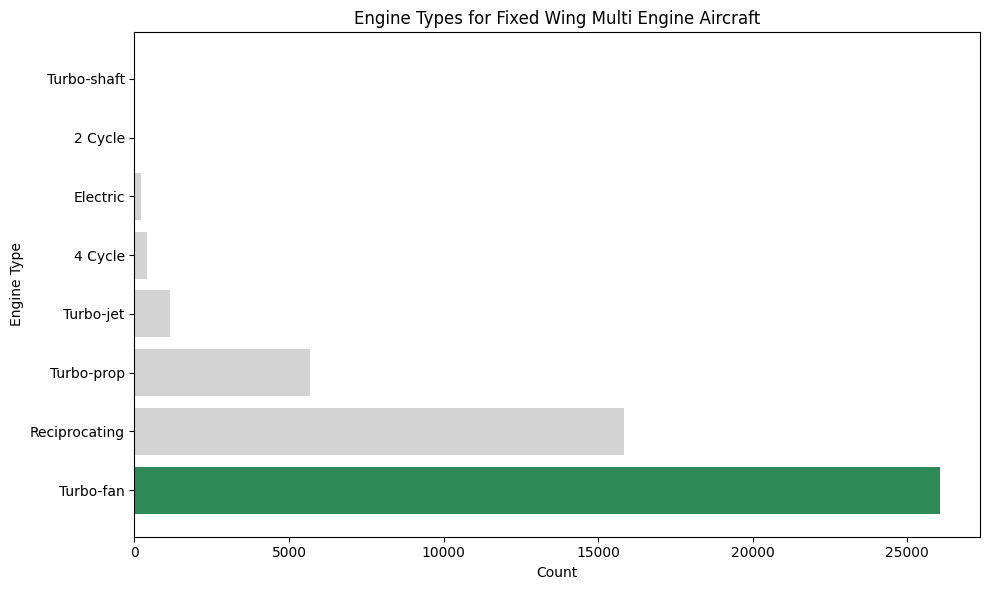

In [36]:
# let's make a new dataframe for fixed wing multi engine aircraft
fixed_wing_multi = aircraft[aircraft['TYPE AIRCRAFT LABEL'] == 'Fixed wing multi engine']

# what is the breakdown of engines for this aircraft?
fwm_engine_counts = fixed_wing_multi['TYPE ENGINE LABEL'].value_counts()

# let's graph the turbo-fan engine for this aircraft type as well
# get cool looking colors, maybe a green
fwm_engine_colors = ['seagreen' if label == 'Turbo-fan' else 'lightgrey' for label in fwm_engine_counts.index]

# plot
fig, ax = plt.subplots(figsize=(10,6))
ax.barh(fwm_engine_counts.index, fwm_engine_counts.values, color=fwm_engine_colors)
ax.set_title('Engine Types for Fixed Wing Multi Engine Aircraft')
ax.set_xlabel('Count')
ax.set_ylabel('Engine Type')
plt.tight_layout()
plt.show()


In [37]:
# what is the shape of our fixed wing multi engine subset of aircraft
print("Full aircarft shape:", aircraft.shape)
print("Fixed wing multi engine:", fixed_wing_multi.shape)

Full aircarft shape: (313930, 19)
Fixed wing multi engine: (49331, 19)


### How has the popularity of this type of aircraft done overtime?

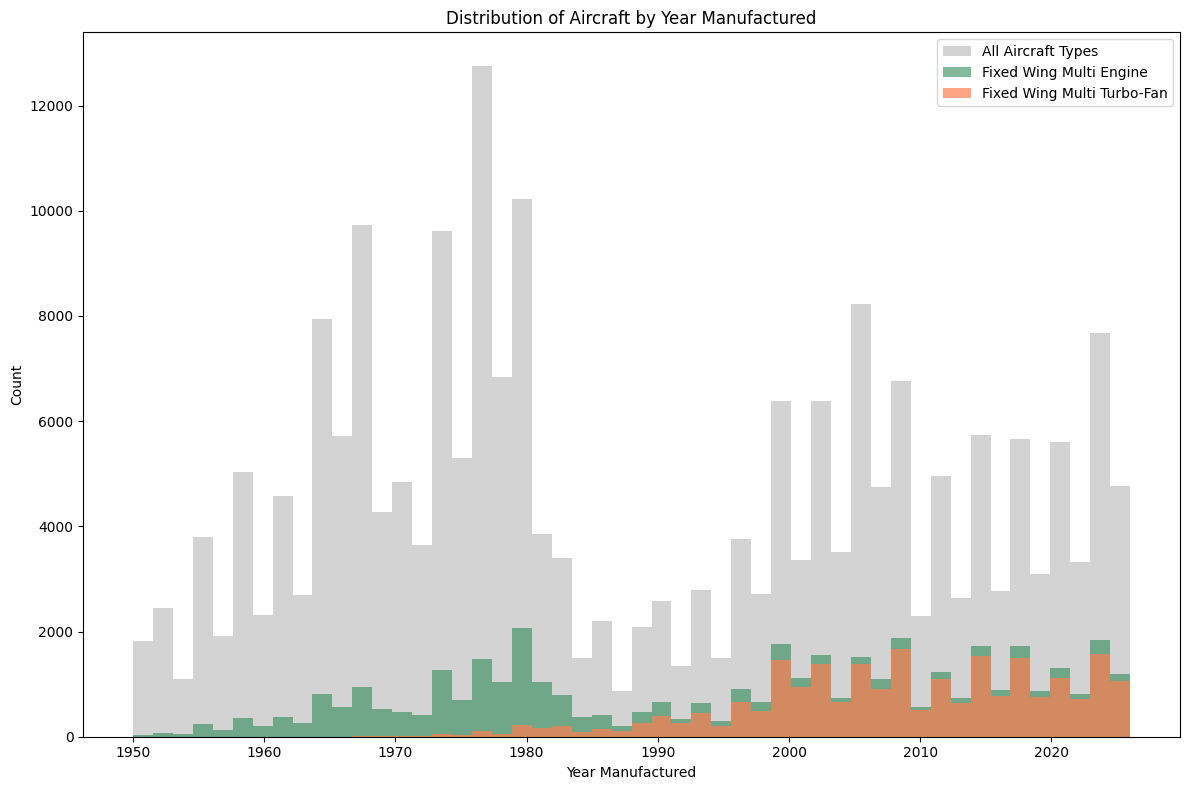

In [38]:
# let's compare the fixed wing multi engine aircraft to others by year manufactured
fig, ax = plt.subplots(figsize=(12, 8))

# let's add the entire aircraft data to the graph
ax.hist(aircraft['YEAR MFR'].dropna(), bins=50, color='lightgrey', label='All Aircraft Types')

# let's show the fixed wing multi engine as green again
ax.hist(fixed_wing_multi['YEAR MFR'].dropna(), bins=50, color='seagreen', label='Fixed Wing Multi Engine', alpha=0.6)

# and last, the fixed wing multi engine turbo-fan
fixed_wing_turbofan = fixed_wing_multi[fixed_wing_multi['TYPE ENGINE LABEL'] == 'Turbo-fan']
ax.hist(fixed_wing_turbofan['YEAR MFR'].dropna(), bins=50, color='coral', label='Fixed Wing Multi Turbo-Fan', alpha=0.7)

# label the graph for readability
ax.set_title('Distribution of Aircraft by Year Manufactured')
ax.set_xlabel('Year Manufactured')
ax.set_ylabel('Count')
ax.legend()

plt.tight_layout()
plt.show()

## The history of this type of aircraft start rising between 1970-1980
Fixed Wing Multi Turbo-Fan planes are currently what most commercial airlines use. The turbo-fan engine gave rise in the 1970's and then became the primary type of engine for Fixed Wing Multi Engine aircraft in the 1990's and through today.

## Supplemental FAA Data
### ACFTREF.txt - aircraft manufacturer and model references

In [39]:
# let's load the aircraft manufacturer data
#aircraft_ref = pd.read_csv('/Users/justin/DATASCI207/207-Summer26-FinalProject-MLModel/datasets/FAA/ACFTREF.txt')
#print("Aircraft reference shape:", aircraft_ref.shape)
#print("Aircraft reference headings:", aircraft_ref.columns.tolist())

In [40]:
aircraft_ref.head()

,CODE,MFR,MODEL,TYPE-ACFT,TYPE-ENG,AC-CAT,BUILD-CERT-IND,NO-ENG,NO-SEATS,AC-WEIGHT,SPEED,TC-DATA-SHEET,TC-DATA-HOLDER,Unnamed: 13
0,0020901,AAR AIRLIFT GROUP INC,UH-60A,6,3,1,0,2,15,CLASS 3,0,,...,NaN
1,0030109,EXLINE ACE-C,ACE-C,4,1,1,1,1,1,CLASS 1,82,,...,NaN
2,003010D,DELEBAUGH,P,4,1,1,1,1,1,CLASS 1,82,,...,NaN
3,003010H,DAL PORTO,BABY ACE D,4,1,1,1,1,1,CLASS 1,82,,...,NaN
4,003010P,DUNN,BABY ACE,4,1,1,1,1,1,CLASS 1,82,,...,NaN


### ENGINE.txt - Engine manufacturer and model references (HP, thrust)

In [41]:
# let's do the same thing for engine reference 
#engine_ref = pd.read_csv('/Users/justin/DATASCI207/207-Summer26-FinalProject-MLModel/datasets/FAA/ENGINE.txt')
#print("Engine reference shape:", engine_ref.shape)
#print("Engine reference headings:", engine_ref.columns.tolist())

In [42]:
# engine_ref.head()

### Merging the supplemental datasets to aircraft master dataframe

In [43]:
# # add in the aircraft reference information like MFR, MODEL, etc.
# aircraft = pd.merge(
#     aircraft, # use all columns from aircraft
#     aircraft_ref[['CODE', 'MFR', 'MODEL', 'NO-ENG', 'NO-SEATS', 'AC-WEIGHT', 'SPEED']], # columns to keep from aircraft_ref
#     left_on='MFR MDL CODE', # use MFR MDL CODE from aicraft for key
#     right_on='CODE', # use CODE from aircraft_ref for pairing
#     how='left' # merge on the left MASTER.txt data
# )

In [44]:
# # check datatype of CODE for each dataset
# print("Engine ref:\n", engine_ref[['CODE']].dtypes)
# print("Aircraft ref:\n", aircraft_ref[['CODE']].dtypes)

# # check aircraft df
# print("Aircraft master:\n", aircraft[['MFR MDL CODE', 'ENG MFR MDL']].dtypes)

# # convert aircraft master 'ENG MFR MDL' to numeric to merge with engine data CODE int65
# aircraft['ENG MFR MDL'] = pd.to_numeric(aircraft['ENG MFR MDL'], errors='coerce')

In [45]:
# # verify new data type of aircraft engines
# print(aircraft[['MFR MDL CODE', 'ENG MFR MDL']].dtypes)

In [46]:
# # let's add the engine information as well

# # we need to convert the datatype for merege to be successful
# aircraft = pd.merge(
#     aircraft, # use the aircraft as master again
#     engine_ref[['CODE', 'MFR', 'MODEL', 'THRUST']], # specific engine information
#     left_on='ENG MFR MDL', # match the ENG MFR MDL in MASTER to the specific engine info
#     right_on='CODE', # match to the code information in engine_ref
#     how='left', # merge to keep all left data
#     suffixes=("", '_ENG') # relabel column headers that have same name
# )

## New EDA on combined data MASTER, aircraft reference, and engine reference

In [47]:
print("Shape of new aircraft df:", aircraft.shape)
print("Columns of aircraft df:", aircraft.columns.tolist())

Shape of new aircraft df: (313930, 19)
Columns of aircraft df: ['N-NUMBER', 'YEAR MFR', 'TYPE AIRCRAFT', 'TYPE ENGINE', 'MFR MDL CODE', 'ENG MFR MDL', 'CODE', 'MFR', 'MODEL', 'NO-ENG', 'NO-SEATS', 'AC-WEIGHT', 'SPEED', 'CODE_ENG', 'MFR_ENG', 'MODEL_ENG', 'THRUST', 'TYPE AIRCRAFT LABEL', 'TYPE ENGINE LABEL']


In [48]:
# how many completed rows do we have with the supplementary data?

# let's check how many of our airplanes had specific aircraft manufacturer data
print("Number of aircraft with known MFR:", aircraft['MFR'].notna().sum())
print("Number of aircraft with unknown MFR:", aircraft['MFR'].isna().sum())

# what percent of our original data had a matching aircraft MFR?
print("Percent of aircraft with known MFR:", aircraft['MFR'].notna().sum() / len(aircraft) *100)

Number of aircraft with known MFR: 313930
Number of aircraft with unknown MFR: 0
Percent of aircraft with known MFR: 100.0


In [49]:
# let's check the engine data
print("Number of aircraft with known ENG MFR:", aircraft['MFR_ENG'].notna().sum())
print("Number of aircraft with unknown ENG MFR:", aircraft['MFR_ENG'].isna().sum())

# what percent of our data is that?
print("Percent of aircraft with known ENG MFR:", aircraft['MFR_ENG'].notna().sum() / len(aircraft) *100)

Number of aircraft with known ENG MFR: 276792
Number of aircraft with unknown ENG MFR: 37138
Percent of aircraft with known ENG MFR: 88.16997419806964


In [50]:
print(aircraft.columns.tolist())

['N-NUMBER', 'YEAR MFR', 'TYPE AIRCRAFT', 'TYPE ENGINE', 'MFR MDL CODE', 'ENG MFR MDL', 'CODE', 'MFR', 'MODEL', 'NO-ENG', 'NO-SEATS', 'AC-WEIGHT', 'SPEED', 'CODE_ENG', 'MFR_ENG', 'MODEL_ENG', 'THRUST', 'TYPE AIRCRAFT LABEL', 'TYPE ENGINE LABEL']


### Let's make a new dataframe to include only the fixed wing multi engine aircraft

In [51]:
# filter for relevant aircraft coming for commercial flights
commercial = aircraft[aircraft['TYPE AIRCRAFT LABEL'] == 'Fixed wing multi engine']

In [52]:
commercial.shape

(49331, 19)

In [53]:
# who makes most of our aircraft?
print("Top manufacturers of commerical aircraft:")
print(commercial['MFR'].value_counts().head(10))

Top manufacturers of commerical aircraft:
MFR
CESSNA                            9564
BEECH                             5820
PIPER                             4913
BOEING                            4768
BOMBARDIER INC                    2992
TEXTRON AVIATION INC              1898
AIRBUS                            1531
RAYTHEON AIRCRAFT COMPANY         1528
GULFSTREAM AEROSPACE              1227
GULFSTREAM AEROSPACE CORP         1007
Name: count, dtype: int64


## We have smaller airline manufactuers composing the top spots in our data (Cessna, Beech, Piper)
- Those are likely private jet or recreational airplanes
- For general commerical flights, companies like Boeing, Airbus, and Bombardier are applicable

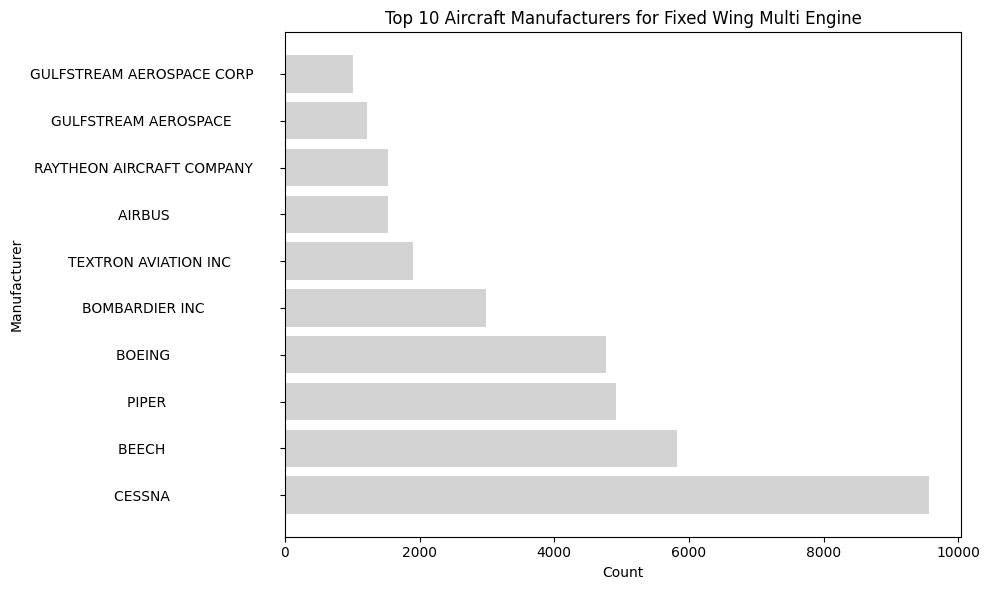

In [54]:
fig, ax = plt.subplots(figsize=(10,6))

top_mfr = commercial['MFR'].value_counts().head(10)
colors = ['steelblue' if mfr in ['BOEING', 'AIRBUS'] else 'lightgrey' for mfr in top_mfr.index]

ax.barh(top_mfr.index, top_mfr.values, color=colors)
ax.set_title('Top 10 Aircraft Manufacturers for Fixed Wing Multi Engine')
ax.set_xlabel('Count')
ax.set_ylabel('Manufacturer')

plt.tight_layout()
plt.show()

In [55]:
print(top_mfr.index.tolist())

['CESSNA                        ', 'BEECH                         ', 'PIPER                         ', 'BOEING                        ', 'BOMBARDIER INC                ', 'TEXTRON AVIATION INC          ', 'AIRBUS                        ', 'RAYTHEON AIRCRAFT COMPANY     ', 'GULFSTREAM AEROSPACE          ', 'GULFSTREAM AEROSPACE CORP     ']


# Correlation Map

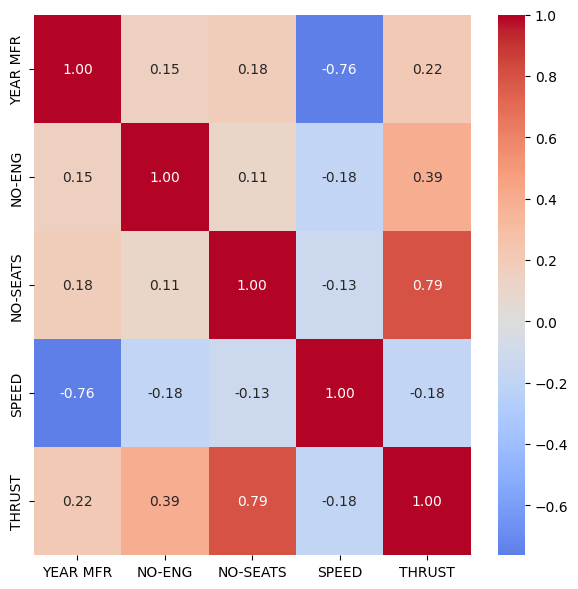

In [58]:
# build the columns to use in the correlation matrix, these are already numberic
column_names = ['YEAR MFR', 'NO-ENG', 'NO-SEATS', 'SPEED', 'THRUST']

# make the correlation matrix
cm = aircraft[column_names].corr()

# plot the matrix
fig, ax = plt.subplots(figsize=(6,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax
)
plt.tight_layout()
plt.show()

The highest correlation we see is from the number of seats (NO-SEATS) and THRUST. 
This could be from larger passenger aircraft needing more thrust during flight.
Also, the NO-ENG number of engines does have some correlation to thrust, likely indicating the more engines the more thrust avail.
The YEAR MFR has a slight correlation with the NO-SEATS, maybe airlines are packing in more passengers?